# Computational Statistics & Data Analysis - Exercise Sheet 3

In [6]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sym
import math
import time

# Task 2

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 
  
# metadata 
print(wine_quality.metadata) 
  
# variable information 
print(wine_quality.variables) 


{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

## 1.)
Standardize each feature:

In [8]:
X_stand=(X-X.mean())/X.std()
X_stand

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,0.142462,2.188664,-2.192664,-0.744721,0.569914,-1.100055,-1.446247,1.034913,1.812950,0.193082,-0.915394
1,0.451001,3.281982,-2.192664,-0.597594,1.197883,-0.311296,-0.862402,0.701432,-0.115064,0.999502,-0.580023
2,0.451001,2.553104,-1.917405,-0.660648,1.026618,-0.874695,-1.092402,0.768128,0.258100,0.797897,-0.580023
3,3.073580,-0.362411,1.660957,-0.744721,0.541370,-0.762016,-0.986248,1.101609,-0.363840,0.327485,-0.580023
4,0.142462,2.188664,-2.192664,-0.744721,0.569914,-1.100055,-1.446247,1.034913,1.812950,0.193082,-0.915394
...,...,...,...,...,...,...,...,...,...,...,...
6492,-0.783154,-0.787590,-0.197039,-0.807775,-0.486215,-0.367636,-0.420095,-1.186069,0.320294,-0.210128,0.593772
6493,-0.474615,-0.119451,0.284664,0.537383,-0.257863,1.491582,0.924517,0.067819,-0.426034,-0.478935,-0.747709
6494,-0.551750,-0.605370,-0.885185,-0.891847,-0.429127,-0.029596,-0.083942,-0.719196,-1.421138,-0.478935,-0.915394
6495,-1.323097,-0.301671,-0.128224,-0.912866,-0.971463,-0.592996,-0.101635,-2.003097,0.755652,-1.016548,1.935253


#### pick alcohol as feature:

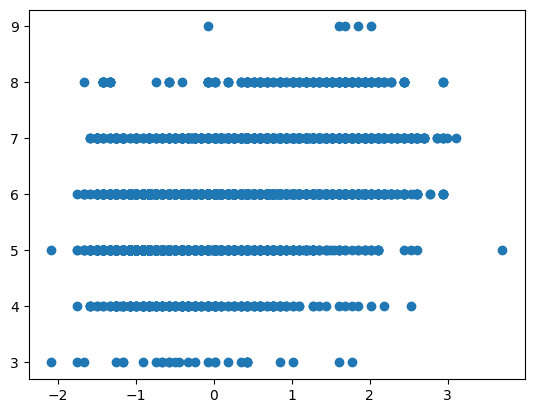

In [14]:
alc=X_stand["alcohol"]
qual=y["quality"]

plt.scatter(alc,qual)

plt.show()

The plot doesn't show a linear behaviour. Therefore at least for alcohol it's not really necessary to use a linear modell.

## 2.
Calculate least squares minimizer:

In [44]:
feat = X_stand.to_numpy()
feat

array([[ 0.1424623 ,  2.18866446, -2.19266376, ...,  1.81294997,
         0.19308191, -0.91539371],
       [ 0.45100101,  3.28198234, -2.19266376, ..., -0.11506417,
         0.99950169, -0.58002349],
       [ 0.45100101,  2.55310376, -1.9174051 , ...,  0.25809985,
         0.79789675, -0.58002349],
       ...,
       [-0.5517498 , -0.60537011, -0.88518515, ..., -1.42113827,
        -0.47893457, -0.91539371],
       [-1.32309658, -0.3016707 , -0.12822384, ...,  0.75565189,
        -1.01654776,  1.93525315],
       [-0.93742319, -0.78758975,  0.42229346, ...,  0.25809985,
        -1.41975765,  1.0968276 ]])

In [56]:
inverse=np.linalg.inv(feat.T@feat)

estimators=inverse@feat.T@y.to_numpy()
estimators

array([[ 0.08774771],
       [-0.21861949],
       [-0.01593507],
       [ 0.20724399],
       [-0.01694623],
       [ 0.10596193],
       [-0.14024759],
       [-0.16482789],
       [ 0.07063319],
       [ 0.11432037],
       [ 0.31848983]])

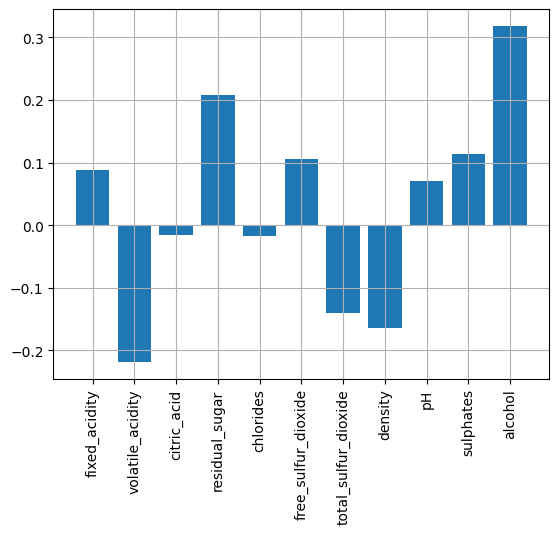

In [65]:
label=X_stand.columns.to_numpy()
plt.bar(label,estimators.flatten())
plt.xticks(rotation=90)
plt.grid()
plt.show()

the quality of wine mostly depends on alcohol, volatile_acidity and residual_sugar.

# Task 3

## likelyhood function:

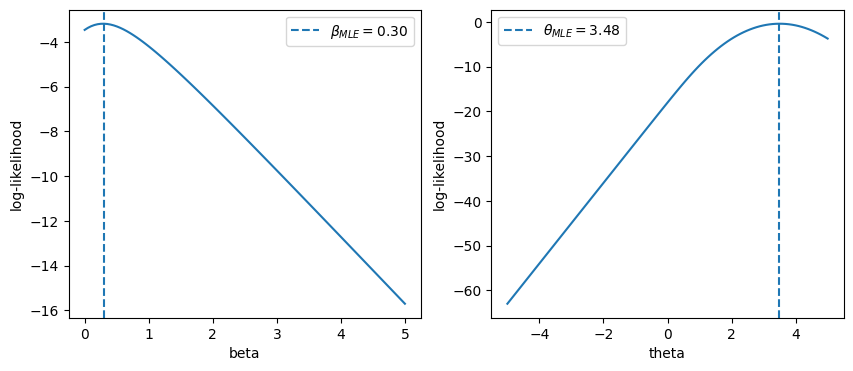

In [84]:
# example data
x = np.array([1, 2, 3, 4, 5])
y = np.array([0, 0, 0, 1, 1])

theta0 = 1
beta0=3

# Sigmoidfunction
def sigma(z):
    return 1 / (1 + np.exp(-z))

# Log-Likelihood
def loglik(beta,theta):
    p = sigma(beta * (x - theta))
    
    return np.sum(y*np.log(p) + (1-y)*np.log(1-p))

# beta
betas = np.linspace(0, 5, 100)

ll_vals = [loglik(b,theta0) for b in betas]

# find maximum
beta_max = betas[np.argmax(ll_vals)]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
# Plot 1
ax[0].plot(betas, ll_vals)
ax[0].axvline(beta_max, linestyle="--",label = fr"$\beta_{{MLE}} = {beta_max:.2f}$")
ax[0].set_xlabel("beta")
ax[0].set_ylabel("log-likelihood")
ax[0].legend()


# theta
thetas = np.linspace(-5, 5, 100)

ll_vals = [loglik(beta0,t) for t in thetas]

# find maximum
theta_max = thetas[np.argmax(ll_vals)]

# Plot 2
ax[1].plot(thetas, ll_vals)
ax[1].axvline(theta_max, linestyle="--",label = fr"$\theta_{{MLE}} = {theta_max:.2f}$")
ax[1].set_xlabel("theta")
ax[1].set_ylabel("log-likelihood")
ax[1].legend()



plt.show()

## least squares:

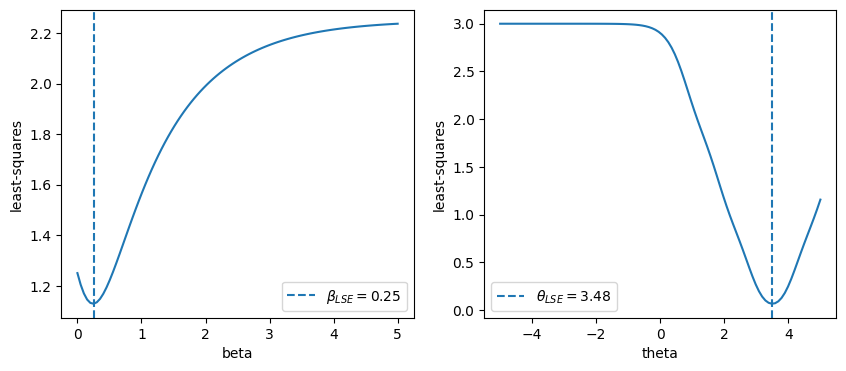

In [87]:
# example data
x = np.array([1, 2, 3, 4, 5])
y = np.array([0, 0, 0, 1, 1])

theta0 = 1
beta0=3

# Sigmoidfunction
def sigma(z):
    return 1 / (1 + np.exp(-z))

# Log-Likelihood
def leastsquares(beta,theta):
    p = sigma(beta * (x - theta))
    
    return np.sum((y-p)**2)

# beta
betas = np.linspace(0, 5, 100)

ll_vals = [leastsquares(b,theta0) for b in betas]

# find maximum
beta_max = betas[np.argmin(ll_vals)]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
# Plot 1
ax[0].plot(betas, ll_vals)
ax[0].axvline(beta_max, linestyle="--",label = fr"$\beta_{{LSE}} = {beta_max:.2f}$")
ax[0].set_xlabel("beta")
ax[0].set_ylabel("least-squares")
ax[0].legend()


# theta
thetas = np.linspace(-5, 5, 100)

ll_vals = [leastsquares(beta0,t) for t in thetas]

# find maximum
theta_max = thetas[np.argmin(ll_vals)]

# Plot 2
ax[1].plot(thetas, ll_vals)
ax[1].axvline(theta_max, linestyle="--",label = fr"$\theta_{{LSE}} = {theta_max:.2f}$")
ax[1].set_xlabel("theta")
ax[1].set_ylabel("least-squares")
ax[1].legend()



plt.show()

# Task 4

In [125]:
mean=np.zeros(49)
for n in range(2,51):
    samples = np.random.exponential(scale=5, size=(50000,n))
    std=np.std(samples,axis=1)
    mean[n-2]=np.mean(std)

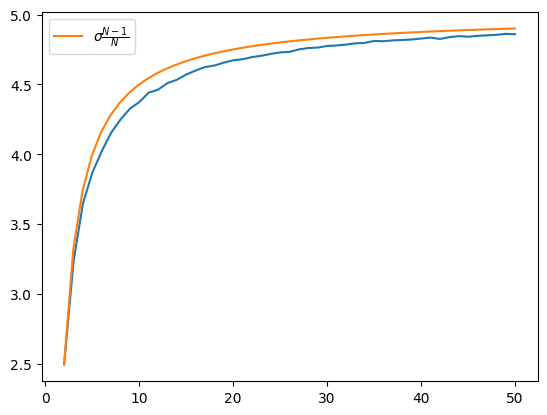

In [126]:
t=np.linspace(2,50)
plt.plot(np.arange(2,51),mean)
plt.plot(t,5*(t-1)/t,label=r"$\sigma \frac{N-1}{N}$")
plt.legend()
plt.show()

In [127]:
std=np.zeros(49)
for n in range(2,51):
    samples = np.random.exponential(scale=5, size=(50000,n))
    mean=np.mean(samples,axis=1)
    std[n-2]=np.std(mean)

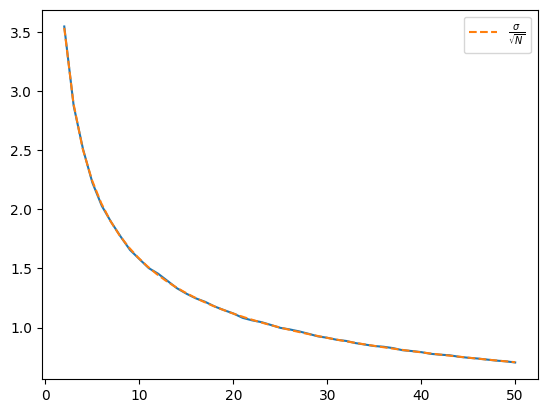

In [130]:
t=np.linspace(2,50)
plt.plot(np.arange(2,51),std)
plt.plot(t,5/np.sqrt(t),"--",label=r"$ \frac{\sigma}{\sqrt{N}}$")
plt.legend()
plt.show()

The standard error of the mean scales with 1/sqrt(N) with sample size